Second derivatives M: [ 0.         -6.54545455  8.18181818 -8.18181818  6.54545455  0.        ]


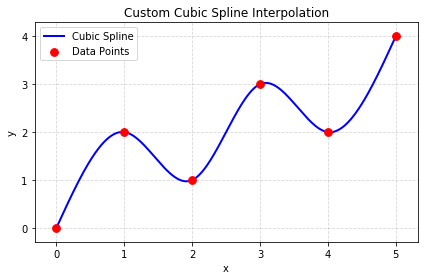

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define Known Data Points
x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([0, 2, 1, 3, 2, 4], dtype=float)

# Step 2: Calculate Step Sizes
def compute_step_sizes(x):
    return np.diff(x)

# Step 3: Set Up and Solve the Tridiagonal System
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = compute_step_sizes(x)
    size = n - 2
    A = np.zeros(size)
    B = np.zeros(size)
    C = np.zeros(size)
    D = np.zeros(size)

    for idx in range(size):
        i = idx + 1
        A[idx] = h[i - 1]
        B[idx] = 2 * (h[i - 1] + h[i])
        C[idx] = h[i]
        D[idx] = 6 * (
            (y[i + 1] - y[i]) / h[i]
            - (y[i] - y[i - 1]) / h[i - 1]
        )

    return A, B, C, D

def thomas_algorithm(a, b, c, d):
    n = len(b)
    b = b.copy()
    d = d.copy()

    # Forward elimination
    for i in range(1, n):
        w = a[i - 1] / b[i - 1]
        b[i] = b[i] - w * c[i - 1]
        d[i] = d[i] - w * d[i - 1]

    # Back substitution
    x_sol = np.zeros(n)
    x_sol[-1] = d[-1] / b[-1]
    for i in range(n - 2, -1, -1):
        x_sol[i] = (d[i] - c[i] * x_sol[i + 1]) / b[i]

    return x_sol

def solve_second_derivatives(x, y):
    n = len(x)
    A, B, C, D = setup_tridiagonal_matrix(x, y)
    M_interior = thomas_algorithm(A, B, C, D)
    M = np.zeros(n)
    M[1:-1] = M_interior
    return M

# Step 4: Evaluate the Spline at New Points
def evaluate_spline(x_data, y_data, M, x_val):
    h = compute_step_sizes(x_data)
    y_eval = np.zeros_like(x_val, dtype=float)  # fixed bug here

    for j, t in enumerate(x_val):
        i = np.searchsorted(x_data, t, side='right') - 1
        i = int(np.clip(i, 0, len(x_data) - 2))
        dx = t - x_data[i]
        hi = h[i]
        a_i = y_data[i]
        b_i = (y_data[i + 1] - y_data[i]) / hi - hi * (2 * M[i] + M[i + 1]) / 6
        c_i = M[i] / 2
        d_i = (M[i + 1] - M[i]) / (6 * hi)
        y_eval[j] = a_i + b_i * dx + c_i * dx**2 + d_i * dx**3

    return y_eval

# plot
M = solve_second_derivatives(x, y)
print("Second derivatives M:", M)

x_fine = np.linspace(x[0], x[-1], 300)
y_fine = evaluate_spline(x, y, M, x_fine)

plt.figure()
plt.plot(x_fine, y_fine, label='Cubic Spline', color='blue', linewidth=2)
plt.scatter(x, y, color='red', zorder=5, label='Data Points', s=60)
plt.title('Custom Cubic Spline Interpolation')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()